In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [2]:
from src.dataset import prepare_dataset
from src.model import build_xception_model
from src.train import compile_model
from src.callbacks import get_callbacks

In [3]:
(
    X_train,
    X_test,
    y_train,
    y_test,
    labels,
    encoder
) = prepare_dataset()

In [4]:
from src.model import build_xception_model
from src.train import compile_model

model = build_xception_model(
    input_shape=(224,224,3),
    num_classes=10
)

model = compile_model(model)

print(model)

<Functional name=functional, built=True>


In [5]:
from src.callbacks import get_callbacks

callbacks = get_callbacks()

print(callbacks)

[<keras.src.callbacks.early_stopping.EarlyStopping object at 0x000002923A01AF90>, <keras.src.callbacks.model_checkpoint.ModelCheckpoint object at 0x0000029269144AD0>]


In [6]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(
        X_test,
        y_test
    ),
    epochs=10,
    batch_size=16,
    callbacks=callbacks
)

Epoch 1/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2687 - loss: 2.1336
Epoch 1: val_accuracy improved from None to 0.84431, saving model to ..\outputs\models\best_model.keras

Epoch 1: finished saving model to ..\outputs\models\best_model.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 168s 4s/step - accuracy: 0.3684 - loss: 1.9160 - val_accuracy: 0.8443 - val_loss: 1.2958
Epoch 2/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7205 - loss: 1.2380
Epoch 2: val_accuracy improved from 0.84431 to 0.95808, saving model to ..\outputs\models\best_model.keras

Epoch 2: finished saving model to ..\outputs\models\best_model.keras
42/42 ━━━━━━━━━━━━━━━━━━━━ 140s 3s/step - accuracy: 0.7759 - loss: 1.1073 - val_accuracy: 0.9581 - val_loss: 0.7432
Epoch 3/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8633 - loss: 0.8140
Epoch 3: val_accuracy did not improve from 0.95808
42/42 ━━━━━━━━━━━━━━━━━━━━ 138s 3s/step - accuracy: 0.8662 - loss: 0.7761 - val_accuracy: 0.9581 - val_loss: 0.4945
E

In [10]:
from src.visualization import (
    plot_training_history,
    plot_loss_history
)

C:\Users\Aditi Mundra\AppData\Local\Temp\ipykernel_8640\1593481034.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


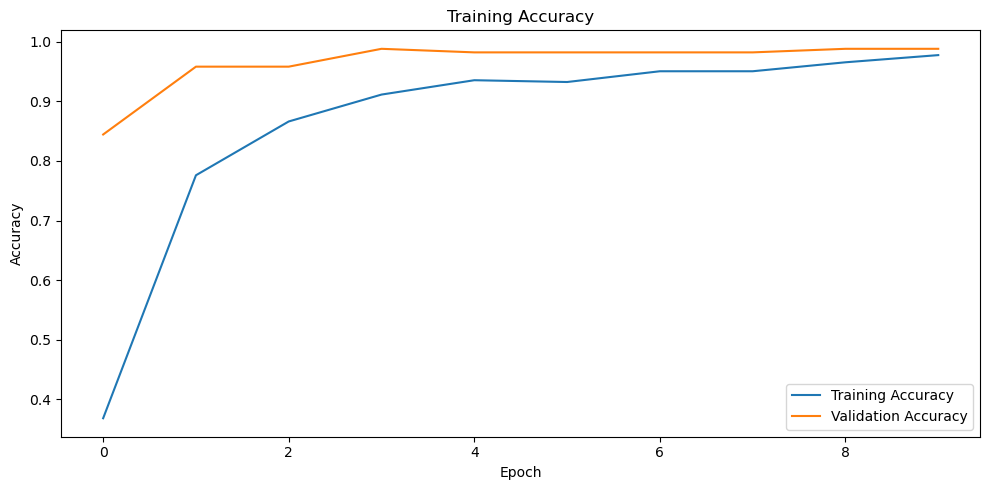

In [11]:
fig = plot_training_history(history)
fig.savefig(
    "../outputs/figures/training_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

fig.show()

In [13]:
fig = plot_loss_history(history)
fig.savefig(
    "../outputs/figures/training_loss.png",
    dpi=300,
    bbox_inches="tight"
)

fig.show()

NameError: name 'pplt' is not defined